# SPRINT 12 – GOLD RECOVERY
Objetivo del proyecto

El objetivo es desarrollar un modelo robusto que prediga con precisión las métricas rougher.output.recovery y final.output.recovery utilizando la métrica sMAPE como criterio de evaluación. Para lograrlo, se deben preparar adecuadamente los datos, analizar su comportamiento, identificar y tratar anomalías, seleccionar características disponibles en producción y validar la calidad del modelo mediante técnicas de validación cruzada.

####  0. IMPORTACIÓN DE LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

plt.style.use("default")
pd.set_option("display.max_columns", None)


#### 1. PREPARACION DE LOS DATOS

##### 1.1. Abrir los archivos y examinar los datos

In [2]:
train = pd.read_csv(r"C:\Users\jonat\Desktop\DATA_SCIENTIST\SPRINT_12_Proyecto_Modulo_2\gold_recovery_train.csv", index_col="date", parse_dates=True)
test  = pd.read_csv(r"C:\Users\jonat\Desktop\DATA_SCIENTIST\SPRINT_12_Proyecto_Modulo_2\gold_recovery_test.csv",  index_col="date", parse_dates=True)
full  = pd.read_csv(r"C:\Users\jonat\Desktop\DATA_SCIENTIST\SPRINT_12_Proyecto_Modulo_2\gold_recovery_full.csv",  index_col="date", parse_dates=True)

In [8]:
print("Shape train:", train.shape)
print("Shape test :", test.shape)
print("Shape full :", full.shape)
print("\nPrimeras filas de train:")
display(train.head())
print("\nInformación general de train:")
train.info()

Shape train: (16860, 87)
Shape test : (5856, 52)
Shape full : (22716, 86)

Primeras filas de train:


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,primary_cleaner.state.floatbank8_d_air,primary_cleaner.state.floatbank8_d_level,rougher.calculation.sulfate_to_au_concentrate,rougher.calculation.floatbank10_sulfate_to_au_feed,rougher.calculation.floatbank11_sulfate_to_au_feed,rougher.calculation.au_pb_ratio,rougher.input.feed_ag,rougher.input.feed_pb,rougher.input.feed_rate,rougher.input.feed_size,rougher.input.feed_sol,rougher.input.feed_au,rougher.input.floatbank10_sulfate,rougher.input.floatbank10_xanthate,rougher.input.floatbank11_sulfate,rougher.input.floatbank11_xanthate,rougher.output.concentrate_ag,rougher.output.concentrate_pb,rougher.output.concentrate_sol,rougher.output.concentrate_au,rougher.output.recovery,rougher.output.tail_ag,rougher.output.tail_pb,rougher.output.tail_sol,rougher.output.tail_au,rougher.state.floatbank10_a_air,rougher.state.floatbank10_a_level,rougher.state.floatbank10_b_air,rougher.state.floatbank10_b_level,rougher.state.floatbank10_c_air,rougher.state.floatbank10_c_level,rougher.state.floatbank10_d_air,rougher.state.floatbank10_d_level,rougher.state.floatbank10_e_air,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,rougher_recovery_calc
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,10.128295,7.25,0.988759,8.547551,10.389648,19.529297,34.174427,14.936526,2.534912,7.476074,2.106679,1549.775757,-498.912140,1551.434204,-516.403442,1549.873901,-498.666595,1554.367432,-493.428131,41885.707031,3481.779053,3520.337158,2.838687,6.100378,2.284912,523.546326,55.486599,36.808594,6.486150,11.986616,6.007990,11.836743,6.005818,11.500771,7.101074,28.029297,19.793808,87.107763,5.008018,0.508728,19.154297,1.170244,999.706909,-404.066986,1603.011353,-434.715027,1602.375000,-442.204468,1598.937256,-451.294128,1404.472046,-455.462982,1416.354980,-451.939636,14.500184,4.694824,8.764648,2.606185,25.853109,-498.526489,23.893660,-501.406281,23.961798,-495.262817,21.940409,-499.340973,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980,87.107763
2016-01-15 01:00:00,6.029369,9.968944


Información general de train:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16788 non-null  float64
 1   final.output.concentrate_pb                         16788 non-null  float64
 2   final.output.concentrate_sol                        16490 non-null  float64
 3   final.output.concentrate_au                         16789 non-null  float64
 4   final.output.recovery                               15339 non-null  float64
 5   final.output.tail_ag                                16794 non-null  float64
 6   final.output.tail_pb                                16677 non-null  float64
 7   final.output.tail_sol                               16715 non-null  float64
 8   final.outp

##### 1.2. Compruebo que el cálculo de la recuperación sea correcto rougher.output.recovery

In [7]:
# Defino la fórmula de recuperación (en %)
def calc_recovery(C, F, T):
    """
    Calcula la recuperación:
    C: ley de oro en el concentrado
    F: ley de oro en la alimentación
    T: ley de oro en las colas
    """
    return (C * (F - T)) / (F * (C - T)) * 100
# Extraigo las columnas necesarias del dataset de entrenamiento
F = train["rougher.input.feed_au"]
C = train["rougher.output.concentrate_au"]
T = train["rougher.output.tail_au"]
# Calculo la recuperación manualmente
train["rougher_recovery_calc"] = calc_recovery(C, F, T)
# Calculo el MAE entre la columna calculada y la columna original rougher.output.recovery
mae_recovery = (train["rougher_recovery_calc"] - train["rougher.output.recovery"]).abs().mean()
print("1.2 MAE entre cálculo y rougher.output.recovery:", mae_recovery)

1.2 MAE entre cálculo y rougher.output.recovery: 9.303415616264301e-15


##### 1.3. Analizo las características no disponibles en el conjunto de prueba

In [9]:
train_cols = set(train.columns)
test_cols  = set(test.columns)
missing_in_test = sorted(list(train_cols - test_cols))
print("1.3  Columnas presentes en train pero no en test:")
for c in missing_in_test:
    print(c)
print("\nTipos de datos de esas columnas:")
display(train[missing_in_test].dtypes)

1.3  Columnas presentes en train pero no en test:
final.output.concentrate_ag
final.output.concentrate_au
final.output.concentrate_pb
final.output.concentrate_sol
final.output.recovery
final.output.tail_ag
final.output.tail_au
final.output.tail_pb
final.output.tail_sol
primary_cleaner.output.concentrate_ag
primary_cleaner.output.concentrate_au
primary_cleaner.output.concentrate_pb
primary_cleaner.output.concentrate_sol
primary_cleaner.output.tail_ag
primary_cleaner.output.tail_au
primary_cleaner.output.tail_pb
primary_cleaner.output.tail_sol
rougher.calculation.au_pb_ratio
rougher.calculation.floatbank10_sulfate_to_au_feed
rougher.calculation.floatbank11_sulfate_to_au_feed
rougher.calculation.sulfate_to_au_concentrate
rougher.output.concentrate_ag
rougher.output.concentrate_au
rougher.output.concentrate_pb
rougher.output.concentrate_sol
rougher.output.recovery
rougher.output.tail_ag
rougher.output.tail_au
rougher.output.tail_pb
rougher.output.tail_sol
rougher_recovery_calc
secondary_cl

final.output.concentrate_ag                           float64
final.output.concentrate_au                           float64
final.output.concentrate_pb                           float64
final.output.concentrate_sol                          float64
final.output.recovery                                 float64
final.output.tail_ag                                  float64
final.output.tail_au                                  float64
final.output.tail_pb                                  float64
final.output.tail_sol                                 float64
primary_cleaner.output.concentrate_ag                 float64
primary_cleaner.output.concentrate_au                 float64
primary_cleaner.output.concentrate_pb                 float64
primary_cleaner.output.concentrate_sol                float64
primary_cleaner.output.tail_ag                        float64
primary_cleaner.output.tail_au                        float64
primary_cleaner.output.tail_pb                        float64
primary_

##### 1.4. Preprocesamiento básico de datos

In [10]:
# Targets (objetivos) que quiero predecir
target_cols = ["rougher.output.recovery", "final.output.recovery"]
# Copia de seguridad del dataset original de entrenamiento
train_original = train.copy()
# Elimino filas donde los targets sean NaN ya que el modelo no puede entrenar con NaN
train = train.dropna(subset=target_cols)
print("1.4 Filas en train después de eliminar NaN en targets:", train.shape[0])

1.4 Filas en train después de eliminar NaN en targets: 14149


#### 2. ANALIZA LOS DATOS

##### 2.1. Cambios en la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación

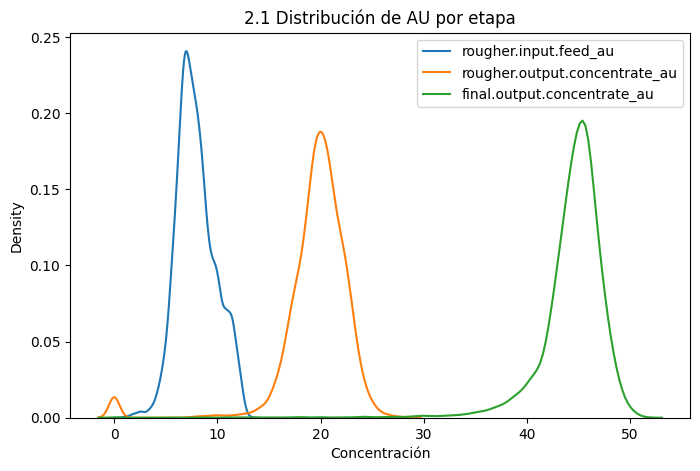

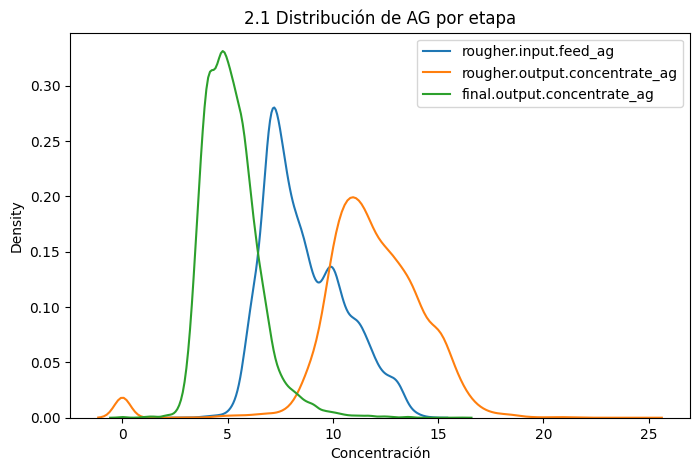

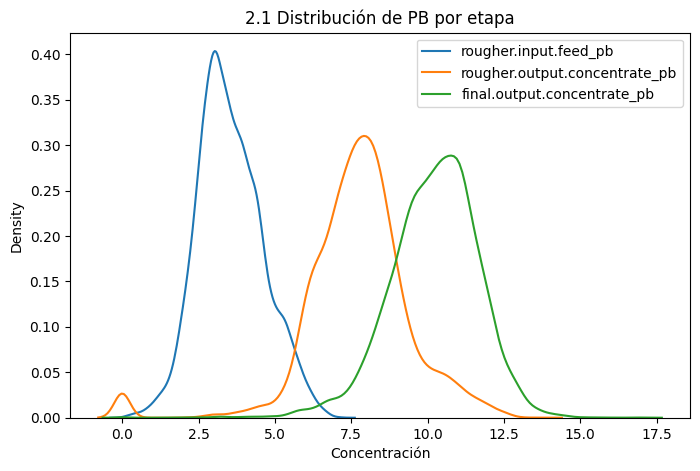

In [17]:
# rougher.input.feed=(materia prima)
# rougher.output.concentrate=(concentrado rougher)
# final.output.concentrate=(concentrado final)
metales = ["au", "ag", "pb"]
etapas = [
    "rougher.input.feed_{}",
    "rougher.output.concentrate_{}",
    "final.output.concentrate_{}"
]

for metal in metales:
    plt.figure(figsize=(8, 5))
    for etapa in etapas:
        col = etapa.format(metal)
        if col in train.columns:
            sns.kdeplot(train[col].dropna(), label=col)
    plt.title(f"2.1 Distribución de {metal.upper()} por etapa")
    plt.xlabel("Concentración")
    plt.legend()
    plt.show()

##### 2.2. Comparación de las distribuciones del tamaño de partículas de la alimentación en train y test

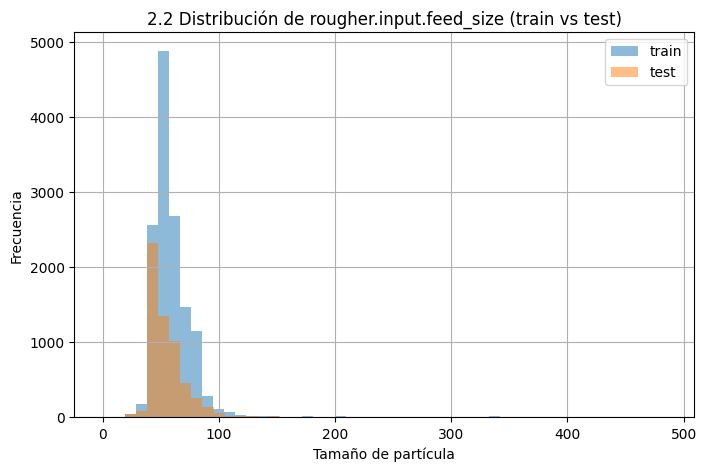

In [16]:
col_size = "rougher.input.feed_size"

plt.figure(figsize=(8, 5))
train[col_size].dropna().hist(alpha=0.5, label="train", bins=50)
test[col_size].dropna().hist(alpha=0.5, label="test", bins=50)
plt.title("2.2 Distribución de rougher.input.feed_size (train vs test)")
plt.xlabel("Tamaño de partícula")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

##### 2.3. Concentraciones totales y eliminación de anomalías

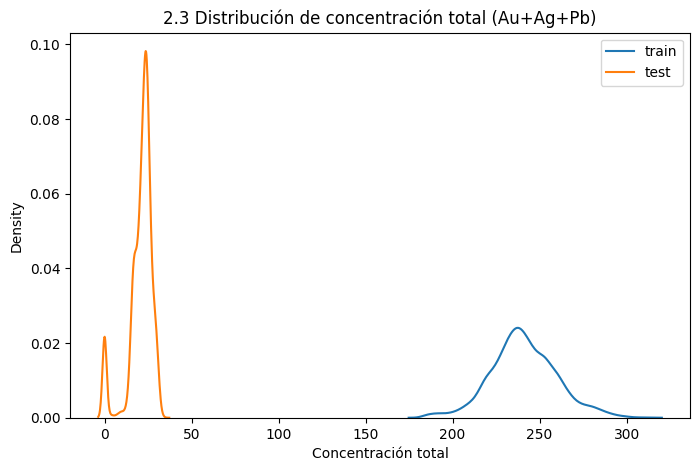

count    13866.000000
mean       240.969196
std         18.964924
min        183.195165
25%        229.118649
50%        239.943270
75%        252.956660
max        311.790412
Name: total_conc, dtype: float64

Umbral (percentil 1) para eliminar anomalías: 192.20523941359858
2.3 Filas en train después de eliminar anomalías: 13727


In [15]:
# Función para calcular la concentración total de Au, Ag y Pb
def total_concentration(df):
    met_cols = [c for c in df.columns if c.endswith("_au") or c.endswith("_ag") or c.endswith("_pb")]
    return df[met_cols].sum(axis=1)
# Calculo la concentración total en train y test
train["total_conc"] = total_concentration(train)
test["total_conc"]  = total_concentration(test)
plt.figure(figsize=(8, 5))
sns.kdeplot(train["total_conc"].dropna(), label="train")
sns.kdeplot(test["total_conc"].dropna(),  label="test")
plt.title("2.3 Distribución de concentración total (Au+Ag+Pb)")
plt.xlabel("Concentración total")
plt.legend()
plt.show()

# Estadísticos básicos para detectar valores con anomalia
print(train["total_conc"].describe())

# Decidi eliminar valores muy bajos de concentración total en train,por ejemplo, por debajo del percentil 1.
# Por lo que ya no necesito la columna auxiliar para el modelado
q_low = train["total_conc"].quantile(0.01)
print("\nUmbral (percentil 1) para eliminar anomalías:", q_low)
train = train[train["total_conc"] > q_low].copy()
print("2.3 Filas en train después de eliminar anomalías:", train.shape[0])
train = train.drop(columns=["total_conc"])
test  = test.drop(columns=["total_conc"])

#### 3. CONSTRUYE EL MODELO

##### 3.1. Funciones de métrica sMAPE y sMAPE final

In [18]:
def smape(y_true, y_pred):
    """
    Calcula el sMAPE para un solo objetivo.
    y_true: valores reales
    y_pred: valores predichos
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    den_safe = np.where(den == 0, 1, den)
    return np.mean(num / den_safe) * 100


def smape_final(y_true, y_pred):
    """
    Calcula la métrica final:
    25% * sMAPE(rougher.output.recovery) + 75% * sMAPE(final.output.recovery)
    y_true y y_pred deben ser arrays 2D de tamaño (n_samples, 2) donde:
        [:, 0] -> rougher.output.recovery
        [:, 1] -> final.output.recovery
    """
    s_rougher = smape(y_true[:, 0], y_pred[:, 0])
    s_final   = smape(y_true[:, 1], y_pred[:, 1])
    return 0.25 * s_rougher + 0.75 * s_final

##### 3.2. Entreno diferentes modelos y los evaluo con validación cruzada

In [20]:
# Vuelvo a definir el conjunto de columnas comunes entre train y test
train_cols = set(train.columns)
test_cols  = set(test.columns)
common_cols = sorted(list(train_cols & test_cols))
print("3.2 Número de columnas comunes train/test:", len(common_cols))
# Matrices de entrenamiento
X_train = train[common_cols].copy()
y_train = train[["rougher.output.recovery", "final.output.recovery"]].copy()
# Matriz de test
X_test = test[common_cols].copy()
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

print("NaN en X_train:", X_train.isna().sum().sum())
print("NaN en X_test :", X_test.isna().sum().sum())
print("NaN en y_train:", y_train.isna().sum().sum())

#Definir el modelo base (RandomForestRegressor multi-output)
model = RandomForestRegressor(
    n_estimators=100,    
    random_state=42,
    n_jobs=-1
)
# Validacion Cruzada
cv = KFold(n_splits=3, shuffle=True, random_state=42)
scores = []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
    
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    
    score = smape_final(y_val.values, y_pred)
    scores.append(score)
    print(f"3.2 sMAPE_final fold {fold}: {score:.4f}")

print("\n3.2 Resultados CV")
print("sMAPE_final promedio:", np.mean(scores))
print("sMAPE_final desviación estándar:", np.std(scores))

3.2 Número de columnas comunes train/test: 52
NaN en X_train: 0
NaN en X_test : 0
NaN en y_train: 0
3.2 sMAPE_final fold 1: 5.7240
3.2 sMAPE_final fold 2: 5.9535
3.2 sMAPE_final fold 3: 5.7412

3.2 Resultados CV
sMAPE_final promedio: 5.80621166904091
sMAPE_final desviación estándar: 0.10435353806324422


##### 3.3 Entrenamiento con el mejor modelo en TODO el conjunto de entrenamiento

In [21]:
model.fit(X_train, y_train)
test_pred = model.predict(X_test)

pred_df = pd.DataFrame(
    test_pred,
    index=X_test.index,
    columns=["rougher.output.recovery", "final.output.recovery"]
)

print("\nPredicciones en test (primeras filas):")
display(pred_df.head())


Predicciones en test (primeras filas):


,rougher.output.recovery,final.output.recovery
date,,
2016-09-01 00:59:59,88.902669,69.611442
2016-09-01 01:59:59,88.200864,69.656680
2016-09-01 02:59:59,87.738545,68.566310
2016-09-01 03:59:59,87.597677,69.398272
2016-09-01 04:59:59,87.484896,68.681693


## Conclusión

Desarrollé un modelo predictivo para estimar la recuperación de oro en dos etapas críticas del proceso metalúrgico: rougher.output.recovery y final.output.recovery. Desde el inicio comprobé que la fórmula de recuperación utilizada por la planta coincidía casi exactamente con los valores proporcionados en el dataset, lo que me permitió confirmar que los datos base eran adecuados para construir el modelo.

Durante la preparación de los datos identifiqué que el conjunto de prueba carecía de varias columnas presentes en el conjunto de entrenamiento, incluyendo las variables objetivo y parámetros generados en etapas posteriores del proceso industrial. Esto me obligó a restringir la modelización a las columnas comunes entre ambos conjuntos y a justificar esta selección. También eliminé las filas que contenían valores faltantes en los objetivos, ya que el modelo no puede entrenar con estos vacíos, y detecté valores con anomalia en la concentración total de metales. Cundo quite los registros correspondientes, mejoré la calidad y consistencia de los datos.

Para el modelado utilicé un RandomForestRegressor en su versión multisalida y lo evalué mediante validación cruzada con tres particiones. Los resultados fueron estables, con un sMAPE_final promedio de aproximadamente 5.8 por ciento y una desviación estándar baja, lo que indica que el modelo tiene un desempeño confiable y consistente. Tras esta evaluación, entrené el modelo con todos los datos disponibles y generé las predicciones correspondientes al conjunto de prueba.